# **Magnetic Tile Defect Classification Problem **

Dataset Source:  https://github.com/Charmve/Surface-Defect-Detection/tree/master/Magnetic-Tile-Defect

# Introduction to the problem

*  Magnetic tiles provide constant magnetic potential as a key component of engines. Automated surface defect detection (filtering unqualified products) is a core research challenge.


The main defects observed are:

*      Blowhole: A small, round cavity on the surface.
*      Crack: A visible line or fissure.
*      Break: A complete separation or fracture.
*      Fray: Edges that appear worn or ragged.
*      Uneven Surface: Irregularities or bumps on the tile.

Source paper: Huang, Y., Qiu, C. & Yuan, K. Surface defect saliency of magnetic tile. Vis Comput 36, 85–96 (2020). https://doi.org/10.1007/s00371-018-1588-5

**Objective: To develop a CNN model to automatically identify and classify a surface defect**

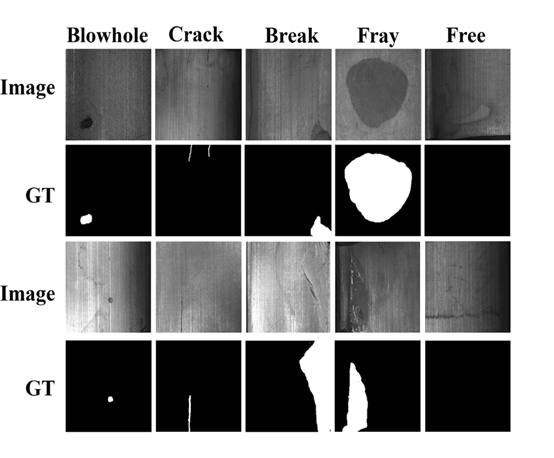

# Library imports

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
from google.colab import files
import zipfile
import os
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import random

# Step 1: Upload and extract the defect classification dataset

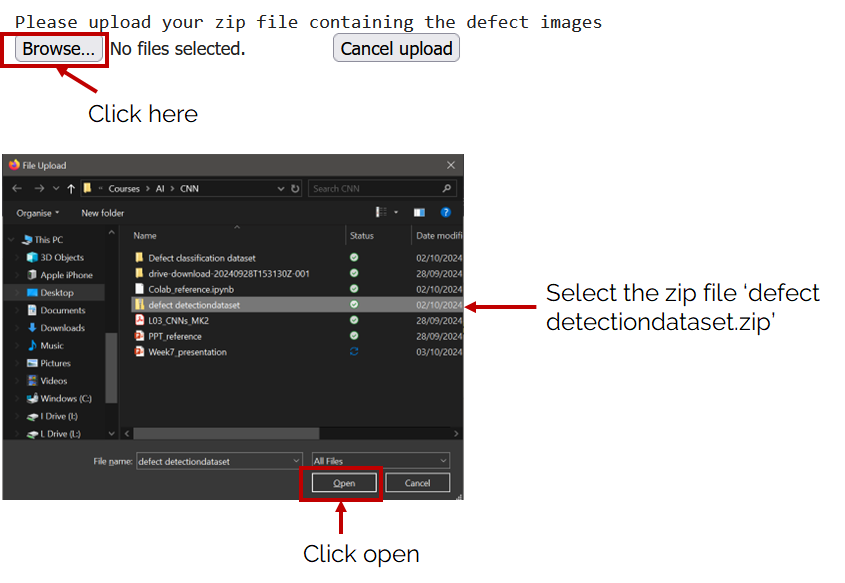

In [ ]:
print("Please upload your zip file containing the defect images")
uploaded = files.upload()
zip_name = list(uploaded.keys())[0]
# Extract the uploaded zip file
with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall('defect_data')

Please upload your zip file containing the defect images


Saving defect detectiondataset.zip to defect detectiondataset (1).zip


# Step 2: Data Preparation
*  Resizing to 128 x 128,
*  Normalizing the pixel values
*  Train-test split
*  'One hot' encoding of outputs - with a single high (1) bit and all the others low (0)


0: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]

1: [0, 1, 0, 0, 0, 0, 0, 0, 0, 0]

2: [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]

3: [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]

4: [0, 0, 0, 0, 1, 0, 0, 0, 0, 0]

5: [0, 0, 0, 0, 0, 1, 0, 0, 0, 0]

6: [0, 0, 0, 0, 0, 0, 1, 0, 0, 0]

7: [0, 0, 0, 0, 0, 0, 0, 1, 0, 0]

8: [0, 0, 0, 0, 0, 0, 0, 0, 1, 0]

9: [0, 0, 0, 0, 0, 0, 0, 0, 0, 1]

In [ ]:
# Step 2: Defining data preparation function (resizing to 128 x 128, and normalizing the pixel values)

def prepare_data(data_dir, target_size=(128, 128)):
    images = []
    labels = []
    class_names = os.listdir(data_dir)

    for class_idx, class_name in enumerate(class_names):
        class_path = os.path.join(data_dir, class_name)
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                # Load and resize image
                img = load_img(img_path, target_size=target_size, color_mode='grayscale')
                img_array = img_to_array(img)
                img_array = img_array / 255.0  # Normalize pixel values
                images.append(img_array)
                labels.append(class_idx)
            except Exception as e:
                print(f"Error loading image {img_path}: {e}")

    return np.array(images), np.array(labels), class_names

# Calling the data preparation function
X, y, class_names = prepare_data('defect_data')
num_classes = len(class_names)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert labels to categorical (one hot encoding)
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)

In [ ]:
#checking the first 10 output data from train dataset after one hot encoding
print (y_train[0:9])
#checking the input and output dimensions
print(X_test.shape)
print(y_test.shape)

[[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0.]]
(87, 128, 128, 1)
(87, 5)


# Step 3: Create the CNN model

In [ ]:
# Step 3: Create the CNN model
def create_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Create and compile the model
model = create_model(X_train.shape[1:], num_classes)
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Print model summary
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 50176)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │       3,211,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │             325 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,267,397 (12.46 MB)

 Trainable params: 3,267,397 (12.46 MB)

 Non-trainable params: 0 (0.00 B)

# Step 4: Train the model

In [ ]:
# Step 4: Train the model
history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_test, y_test))

Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 549ms/step - accuracy: 0.5116 - loss: 1.4127 - val_accuracy: 0.8161 - val_loss: 0.5653
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 444ms/step - accuracy: 0.8566 - loss: 0.4805 - val_accuracy: 0.8966 - val_loss: 1.0386
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 518ms/step - accuracy: 0.8992 - loss: 1.1054 - val_accuracy: 0.8621 - val_loss: 0.3699
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 459ms/step - accuracy: 0.9269 - loss: 0.2171 - val_accuracy: 0.9080 - val_loss: 0.3037
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 480ms/step - accuracy: 0.9561 - loss: 0.1682 - val_accuracy: 0.9195 - val_loss: 0.3160
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 443ms/step - accuracy: 0.9775 - loss: 0.0767 - val_accuracy: 0.9195 - val_loss: 0.4235
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 475ms/step - accuracy: 0.9787 - loss: 0.0611 - val_accuracy: 0.9195 - val_loss: 0.5073
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 578ms/step - accuracy: 0.9761 - loss: 0.0476 - val_accuracy: 0.

# Step 5: Evaluate the model

In [ ]:
# Step 5: Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f'\nTest accuracy: {test_acc}')

3/3 - 0s - 109ms/step - accuracy: 0.9425 - loss: 0.5767

Test accuracy: 0.9425287246704102


# Step 6: Plot training history

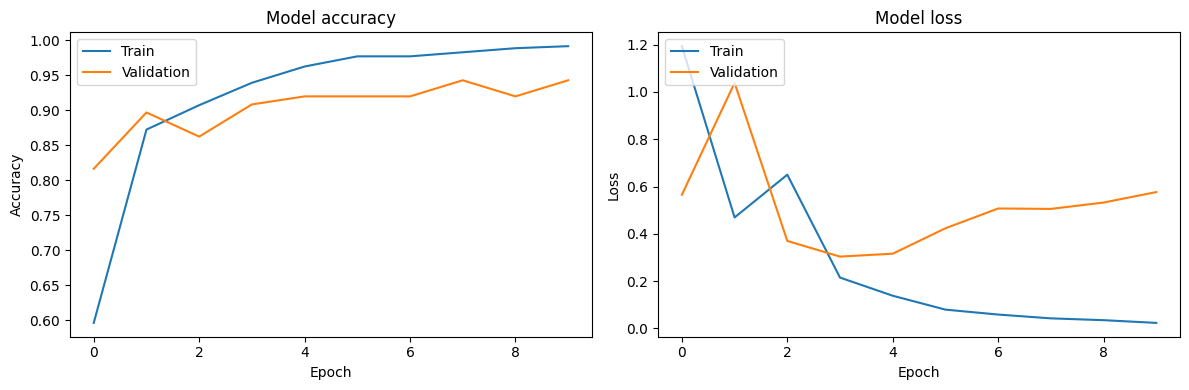

In [ ]:
# Step 6: Plot training history
plt.figure(figsize=(12, 4))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()



# Step 7: Create confusion matrix

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step


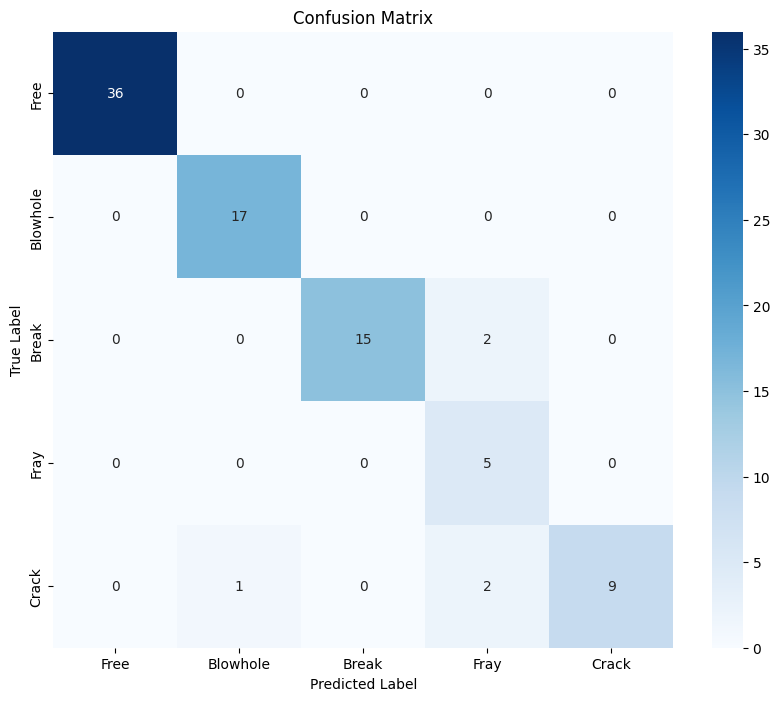

In [ ]:
# Step 7: Create confusion matrix
# Get predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# Create confusion matrix
cm = confusion_matrix(y_test_classes, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Step 8: Select and display a random test image with prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


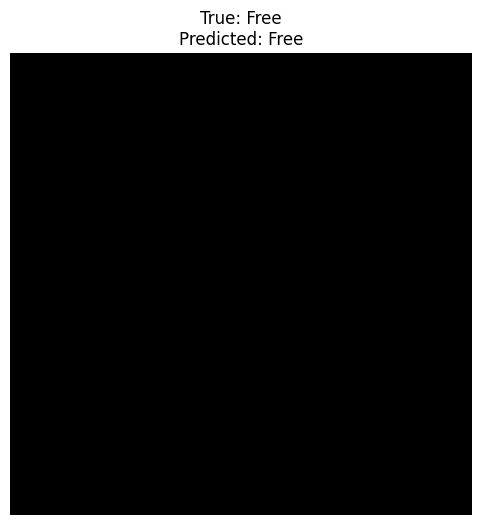


Classification Report:
              precision    recall  f1-score   support

        Free       1.00      1.00      1.00        36
    Blowhole       0.94      1.00      0.97        17
       Break       1.00      0.88      0.94        17
        Fray       0.56      1.00      0.71         5
       Crack       1.00      0.75      0.86        12

    accuracy                           0.94        87
   macro avg       0.90      0.93      0.90        87
weighted avg       0.96      0.94      0.95        87



In [ ]:
# Step 8: Select and display a random test image with prediction
def display_random_test_image(X_test, y_test_classes, model, class_names):
    # Select random index
    idx = random.randint(0, len(X_test) - 1)

    # Get the image and true label
    test_image = X_test[idx]
    true_class = class_names[y_test_classes[idx]]

    # Get prediction
    prediction = model.predict(np.expand_dims(test_image, axis=0))
    predicted_class = class_names[np.argmax(prediction)]

    # Display image and results
    plt.figure(figsize=(6, 6))
    plt.imshow(np.squeeze(test_image), cmap='gray')
    plt.title(f'True: {true_class}\nPredicted: {predicted_class}')
    plt.axis('off')
    plt.show()

# Display random test image
display_random_test_image(X_test, y_test_classes, model, class_names)

# Print classification report
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(y_test_classes, y_pred_classes, target_names=class_names))